# ***Traffic Sign Recognition using CNN***

In [1]:
!pip install tensorflow scikit-learn pillow -q

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train (1).csv


In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

os.makedirs("plots", exist_ok=True)
IMG_SIZE = 32
NUM_CLASSES = 43
RANDOM_STATE = 42

CLASS_NAMES = {
    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing for vehicles over 3.5 metric tons",
    11: "Right-of-way at the next intersection", 12: "Priority road", 13: "Yield",
    14: "Stop", 15: "No vehicles", 16: "Vehicles over 3.5 metric tons prohibited",
    17: "No entry", 18: "General caution", 19: "Dangerous curve to the left",
    20: "Dangerous curve to the right", 21: "Double curve", 22: "Bumpy road",
    23: "Slippery road", 24: "Road narrows on the right", 25: "Road work",
    26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End of all speed and passing limits", 33: "Turn right ahead",
    34: "Turn left ahead", 35: "Ahead only", 36: "Go straight or right",
    37: "Go straight or left", 38: "Keep right", 39: "Keep left",
    40: "Roundabout mandatory", 41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 metric tons",
}

Load and preprocess images

In [5]:
df = pd.read_csv("Train.csv")
print(f"Found {len(df)} training images across {df['ClassId'].nunique()} classes")

images, labels = [], []
for i, row in df.iterrows():
    img_path = row["Path"]
    try:
        img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        images.append(np.array(img))
        labels.append(row["ClassId"])
    except Exception as e:
        print(f"Skipped {img_path}: {e}")
        continue
    if i % 5000 == 0 and i > 0:
        print(f"  ...loaded {i} images")

X = np.array(images, dtype="float32") / 255.0
y = np.array(labels)
print(f"Finished loading. X shape: {X.shape}, y shape: {y.shape}")

Found 39209 training images across 43 classes
  ...loaded 5000 images
  ...loaded 10000 images
  ...loaded 15000 images
  ...loaded 20000 images
  ...loaded 25000 images
  ...loaded 30000 images
  ...loaded 35000 images
Finished loading. X shape: (39209, 32, 32, 3), y shape: (39209,)


EDA — class distribution

Train/test split

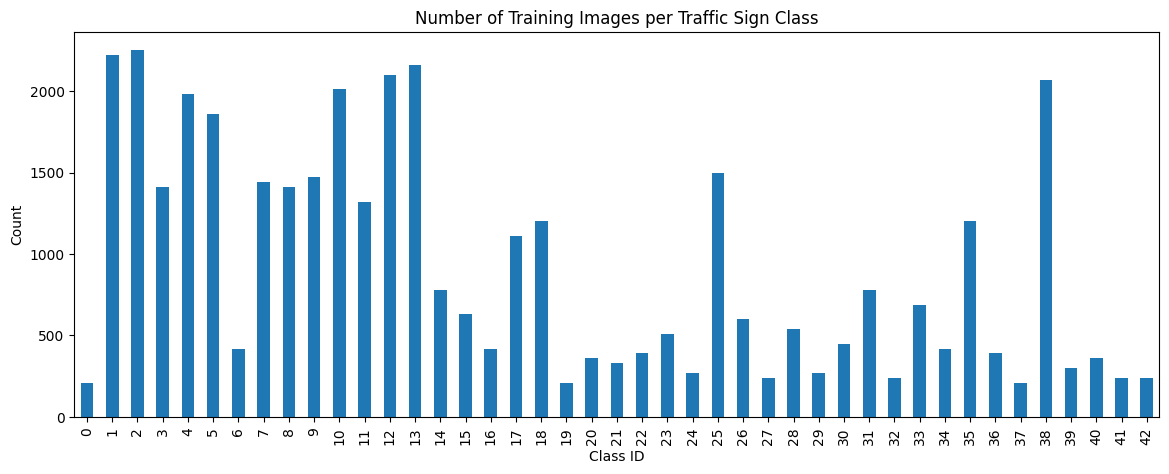

In [6]:
counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(14, 5))
counts.plot(kind="bar")
plt.title("Number of Training Images per Traffic Sign Class")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.savefig("plots/class_distribution.png", bbox_inches="tight")
plt.show()

Build the CNN

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 31367, Test size: 7842


Train the model

In [8]:
def build_model(num_classes):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model = build_model(NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,126,859 (4.30 MB)

 Trainable params: 1,126,155 (4.30 MB)

 Non-trainable params: 704 (2.75 KB)

Train the Model

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 199s 426ms/step - accuracy: 0.7399 - loss: 1.0044 - val_accuracy: 0.7408 - val_loss: 1.0806
Epoch 2/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 202s 427ms/step - accuracy: 0.9701 - loss: 0.1241 - val_accuracy: 0.9917 - val_loss: 0.0471
Epoch 3/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 196s 413ms/step - accuracy: 0.9852 - loss: 0.0602 - val_accuracy: 0.9943 - val_loss: 0.0226
Epoch 4/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 184s 417ms/step - accuracy: 0.9846 - loss: 0.0567 - val_accuracy: 0.9898 - val_loss: 0.0324
Epoch 5/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 211s 438ms/step - accuracy: 0.9913 - loss: 0.0327 - val_accuracy: 0.9978 - val_loss: 0.0112
Epoch 6/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 184s 415ms/step - accuracy: 0.9923 - loss: 0.0274 - val_accuracy: 0.9962 - val_loss: 0.0155
Epoch 7/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 181s 410ms/step - accuracy: 0.9945 - loss: 0.0203 - val_accuracy: 0.9955 - val_loss: 0.0147
Epoch 8/25
442/442 ━━━━━━━━━━━━━━━━━━━━ 202s 411ms/step - accuracy: 0.9956 -

Plot training history

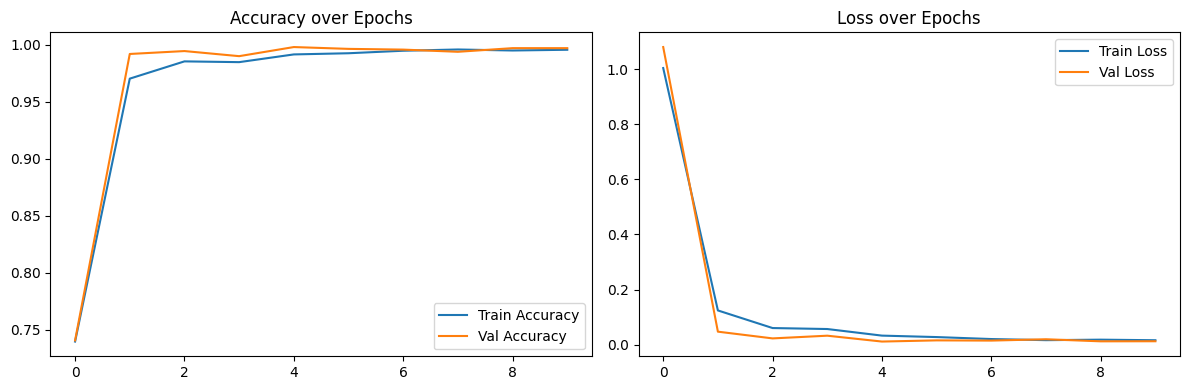

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].legend()

plt.tight_layout()
plt.savefig("plots/training_history.png", bbox_inches="tight")
plt.show()

Evaluate on test set

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

Test Accuracy: 0.9972 | Test Loss: 0.0151

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        42
           1     0.9977    0.9955    0.9966       444
           2     1.0000    0.9956    0.9978       450
           3     0.9895    1.0000    0.9947       282
           4     0.9950    1.0000    0.9975       396
           5     0.9973    0.9892    0.9933       372
           6     1.0000    1.0000    1.0000        84
           7     1.0000    0.9965    0.9983       288
           8     1.0000    0.9965    0.9982       282
           9     1.0000    0.9966    0.9983       294
          10     0.9926    1.0000    0.9963       402
          11     1.0000    1.0000    1.0000       264
          12     1.0000    1.0000    1.0000       420
          13     0.9954    1.0000    0.9977       432
          14     0.9936    1.0000    0.9968       156
          15     1.0000    1.0000    1.0000       126
          16   

Confusion matrix

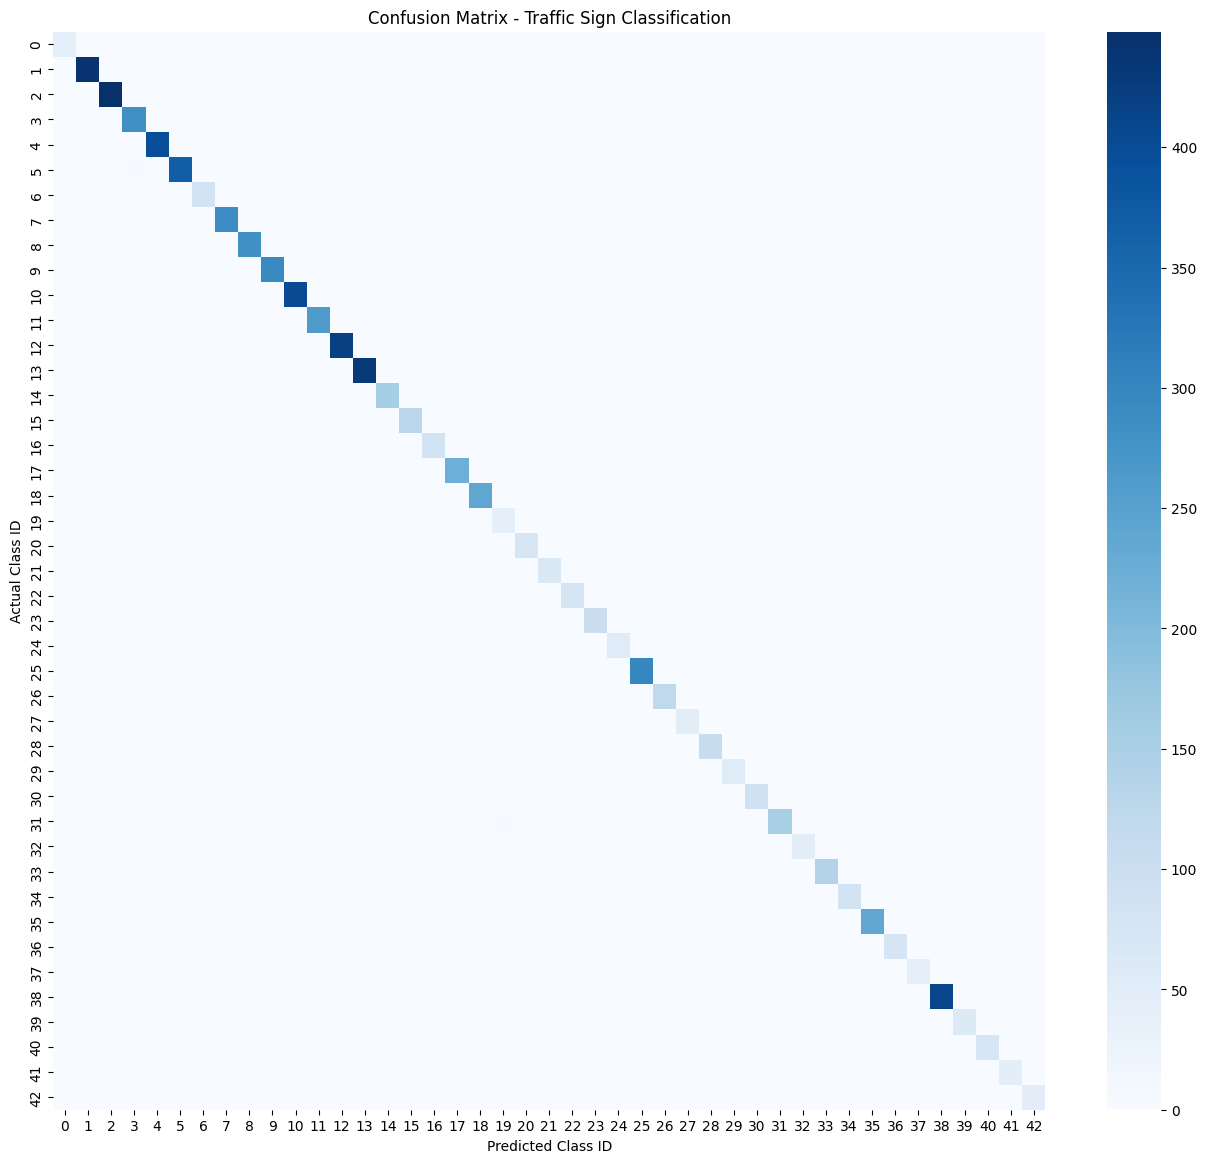

In [12]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title("Confusion Matrix - Traffic Sign Classification")
plt.xlabel("Predicted Class ID")
plt.ylabel("Actual Class ID")
plt.savefig("plots/confusion_matrix.png", bbox_inches="tight")
plt.show()

Sample Predictions

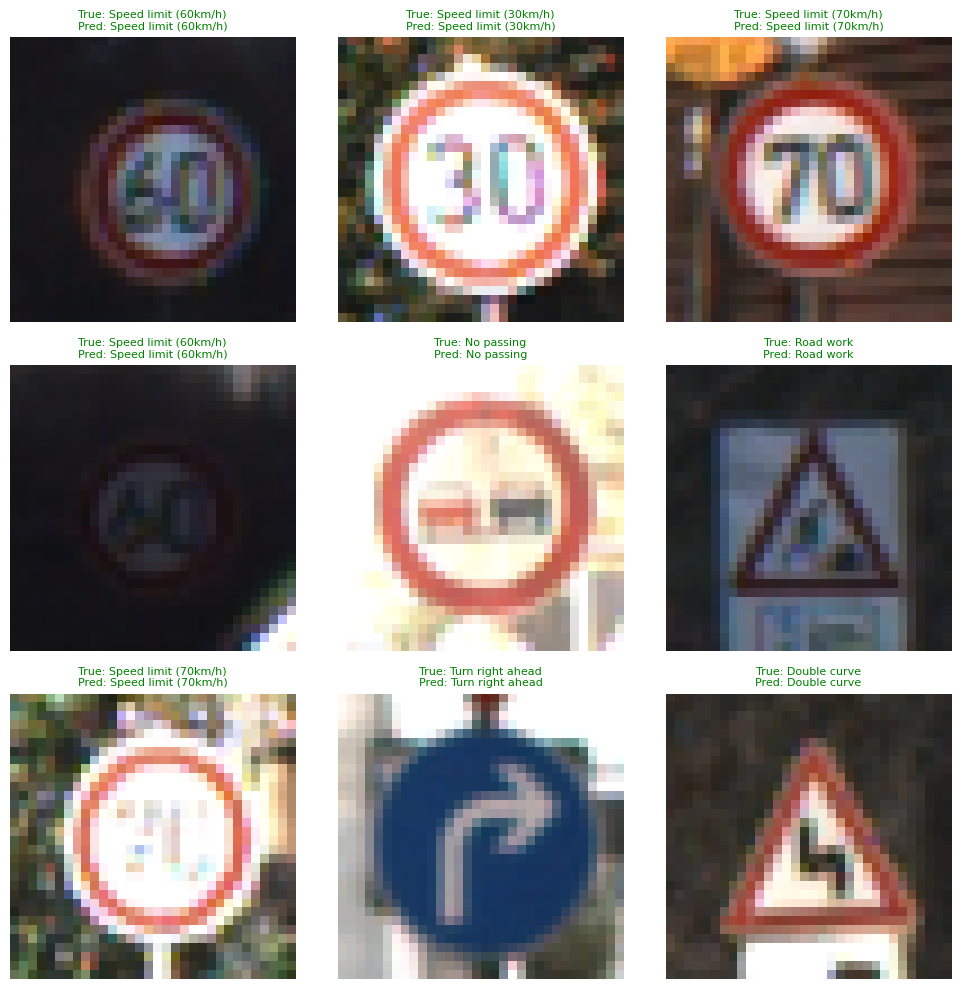

In [13]:
plt.figure(figsize=(10, 10))
idxs = np.random.choice(len(X_test), size=9, replace=False)
for i, idx in enumerate(idxs):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx])
    true_label = CLASS_NAMES.get(int(y_test[idx]), str(y_test[idx]))
    pred_label = CLASS_NAMES.get(int(y_pred[idx]), str(y_pred[idx]))
    color = "green" if y_test[idx] == y_pred[idx] else "red"
    plt.title(f"True: {true_label[:20]}\nPred: {pred_label[:20]}", fontsize=8, color=color)
    plt.axis("off")
plt.tight_layout()
plt.savefig("plots/sample_predictions.png", bbox_inches="tight")
plt.show()

In [14]:
model.save("traffic_sign_model.keras")
with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

print("Saved model to 'traffic_sign_model.keras'")
print("Saved class names to 'class_names.json'")

Saved model to 'traffic_sign_model.keras'
Saved class names to 'class_names.json'


Predict on a single uploaded image

In [16]:
uploaded = files.upload()  # upload any traffic sign image
img_path = list(uploaded.keys())[0]

img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
img_array = np.expand_dims(np.array(img, dtype="float32") / 255.0, axis=0)

predictions = model.predict(img_array, verbose=0)[0]
top_idx = int(np.argmax(predictions))
print(f"Prediction: {CLASS_NAMES.get(top_idx, top_idx)}")
print(f"Confidence: {predictions[top_idx]*100:.2f}%")

Saving Stop.png to Stop.png
Prediction: Stop
Confidence: 74.82%


In [17]:
from sklearn.decomposition import PCA

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Reduce dimensionality — raw flattened images (32*32*3=3072 features) are too many for KNN/DT
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance retained: 90.96%


KNN Classification

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca)

print("=== KNN ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn, zero_division=0))

=== KNN ===
Accuracy: 0.8855
              precision    recall  f1-score   support

           0       0.71      0.86      0.77        42
           1       0.84      0.93      0.88       444
           2       0.85      0.84      0.85       450
           3       0.78      0.82      0.80       282
           4       0.84      0.84      0.84       396
           5       0.79      0.84      0.82       372
           6       0.96      0.95      0.96        84
           7       0.80      0.86      0.83       288
           8       0.77      0.85      0.81       282
           9       0.94      0.94      0.94       294
          10       0.90      0.88      0.89       402
          11       0.94      0.84      0.88       264
          12       0.96      0.92      0.94       420
          13       0.97      0.95      0.96       432
          14       0.99      0.88      0.93       156
          15       0.93      0.86      0.89       126
          16       0.90      0.96      0.93        8

Decision Tree Classification

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=15, random_state=42)
dt.fit(X_train_pca, y_train)
y_pred_dt = dt.predict(X_test_pca)

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, zero_division=0))

=== Decision Tree ===
Accuracy: 0.5565
              precision    recall  f1-score   support

           0       0.27      0.14      0.19        42
           1       0.46      0.54      0.50       444
           2       0.39      0.48      0.43       450
           3       0.36      0.38      0.37       282
           4       0.51      0.54      0.52       396
           5       0.33      0.48      0.39       372
           6       0.62      0.56      0.59        84
           7       0.37      0.33      0.34       288
           8       0.47      0.48      0.47       282
           9       0.61      0.66      0.63       294
          10       0.64      0.65      0.65       402
          11       0.59      0.52      0.56       264
          12       0.71      0.70      0.71       420
          13       0.72      0.73      0.72       432
          14       0.56      0.59      0.57       156
          15       0.50      0.43      0.46       126
          16       0.68      0.62      0.6

Random Forest Classification

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== Random Forest ===
Accuracy: 0.8985
              precision    recall  f1-score   support

           0       1.00      0.38      0.55        42
           1       0.77      0.94      0.85       444
           2       0.85      0.90      0.87       450
           3       0.83      0.84      0.83       282
           4       0.86      0.86      0.86       396
           5       0.78      0.83      0.81       372
           6       0.98      0.96      0.97        84
           7       0.93      0.81      0.86       288
           8       0.90      0.86      0.88       282
           9       0.91      0.93      0.92       294
          10       0.89      0.92      0.91       402
          11       0.82      0.90      0.86       264
          12       0.91      0.98      0.94       420
          13       0.95      1.00      0.97       432
          14       0.97      0.93      0.95       156
          15       0.97      0.81      0.88       126
          16       1.00      0.93      0.9

Clustering (K-Means)

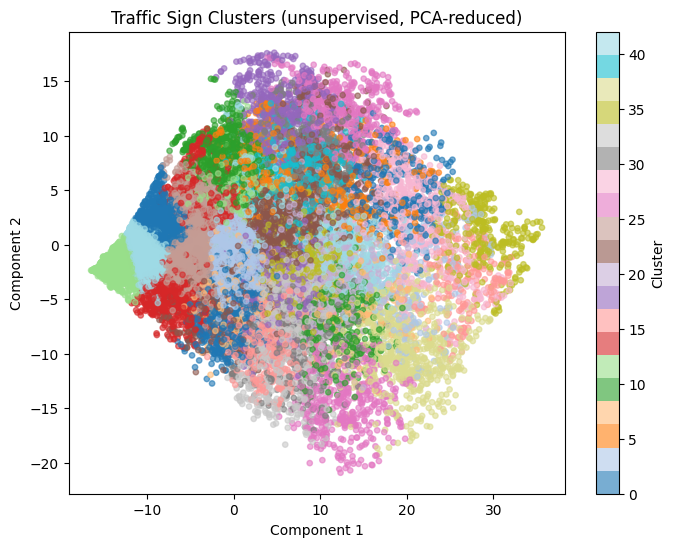

Adjusted Rand Index (cluster vs. true class agreement): 0.0322


In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=NUM_CLASSES, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_pca)

# Visualize in 2D
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap='tab20', alpha=0.6, s=15)
plt.title("Traffic Sign Clusters (unsupervised, PCA-reduced)")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.savefig("plots/traffic_sign_clusters.png", bbox_inches="tight")
plt.show()

# How well do clusters line up with true classes?
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y_train, cluster_labels)
print(f"Adjusted Rand Index (cluster vs. true class agreement): {ari:.4f}")

Recurrent Neural Network

In [27]:
# Traffic sign images aren't naturally sequential, but this is a classic technique:
# treat each row of the image as a "time step" fed into an LSTM.
X_train_seq = X_train.reshape(X_train.shape[0], IMG_SIZE, IMG_SIZE * 3)
X_test_seq = X_test.reshape(X_test.shape[0], IMG_SIZE, IMG_SIZE * 3)

rnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE * 3)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
rnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

rnn_history = rnn.fit(
    X_train_seq, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1,
)

rnn_test_loss, rnn_test_acc = rnn.evaluate(X_test_seq, y_test, verbose=0)
print(f"RNN Test Accuracy: {rnn_test_acc:.4f}")

Epoch 1/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 53s 48ms/step - accuracy: 0.1808 - loss: 2.8817 - val_accuracy: 0.3669 - val_loss: 2.0008
Epoch 2/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.4251 - loss: 1.7917 - val_accuracy: 0.5537 - val_loss: 1.3293
Epoch 3/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.5847 - loss: 1.2633 - val_accuracy: 0.6557 - val_loss: 1.0297
Epoch 4/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.7004 - loss: 0.9211 - val_accuracy: 0.7424 - val_loss: 0.7709
Epoch 5/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.7747 - loss: 0.7017 - val_accuracy: 0.8103 - val_loss: 0.6109
Epoch 6/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step - accuracy: 0.8254 - loss: 0.5541 - val_accuracy: 0.8597 - val_loss: 0.4454
Epoch 7/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - accuracy: 0.8672 - loss: 0.4331 - val_accuracy: 0.8875 - val_loss: 0.3681
Epoch 8/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - accuracy: 0.8947 - loss: 0.3539 - 

NLP — semantic grouping of traffic sign label names

In [23]:
# This applies real NLP — but to the CLASS LABEL TEXT, not the images themselves,
# since raw image classification has no natural text component.
from sklearn.feature_extraction.text import TfidfVectorizer

label_texts = list(CLASS_NAMES.values())
vectorizer = TfidfVectorizer()
X_text = vectorizer.fit_transform(label_texts)

# Group sign names into semantic categories (e.g., all "Speed limit" signs together)
n_semantic_groups = 6
km_text = KMeans(n_clusters=n_semantic_groups, random_state=42, n_init=10)
semantic_clusters = km_text.fit_predict(X_text)

semantic_df = pd.DataFrame({
    "class_id": list(CLASS_NAMES.keys()),
    "label": label_texts,
    "semantic_group": semantic_clusters
}).sort_values("semantic_group")
print(semantic_df.to_string(index=False))

 class_id                                              label  semantic_group
       12                                      Priority road               0
       25                                          Road work               0
       23                                      Slippery road               0
       22                                         Bumpy road               0
       24                          Road narrows on the right               0
        0                               Speed limit (20km/h)               1
        2                               Speed limit (50km/h)               1
        1                               Speed limit (30km/h)               1
        7                              Speed limit (100km/h)               1
        8                              Speed limit (120km/h)               1
        6                        End of speed limit (80km/h)               1
        3                               Speed limit (60km/h)               1

 Compare all classical models + CNN + RNN

In [28]:
comparison = pd.DataFrame([
    {"Model": "KNN", "Accuracy": accuracy_score(y_test, y_pred_knn)},
    {"Model": "Decision Tree", "Accuracy": accuracy_score(y_test, y_pred_dt)},
    {"Model": "Random Forest", "Accuracy": accuracy_score(y_test, y_pred_rf)},
    {"Model": "RNN (LSTM)", "Accuracy": rnn_test_acc},
    # Add "CNN" row after you run your existing CNN training cells:
    # {"Model": "CNN", "Accuracy": test_acc},
])
print(comparison.to_string(index=False))
comparison.to_csv("model_comparison_all.csv", index=False)

        Model  Accuracy
          KNN  0.885488
Decision Tree  0.556491
Random Forest  0.898495
   RNN (LSTM)  0.928845
